# EXPT NO. 6 — IMPLEMENTATION OF LSTM FOR SENTIMENT ANALYSIS


## Aim
To implement a Long Short-Term Memory (LSTM) network for sentiment analysis by performing text preprocessing, tokenization, sequence generation, and embedding using NLP libraries, and classify text into sentiment categories.

## Software Requirements
- Python
- TensorFlow / Keras
- Google Colab
- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- NLP preprocessing libraries

## Dataset
**IMDB Movie Reviews Dataset:**  
https://ai.stanford.edu/~amaas/data/sentiment/

The notebook downloads the official IMDB dataset automatically in Part A.


## Objectives
1. Understand the architecture and working of LSTM networks.
2. Perform text preprocessing techniques for sentiment analysis.
3. Tokenize and convert textual data into numerical sequences.
4. Generate word embeddings for textual data.
5. Build and train an LSTM model for sentiment classification.
6. Evaluate the performance of the trained LSTM model.
7. Analyze the effect of preprocessing and embedding on sentiment classification.


# Procedure

### Part A — Dataset Preparation and Text Preprocessing
- Load the IMDB Movie Reviews dataset.
- Explore sample positive and negative reviews.
- Check the number of samples and sentiment class distribution.
- Convert text to lowercase.
- Remove unnecessary punctuation and special characters.
- Tokenize reviews into numerical sequences.
- Build a vocabulary from the training reviews.
- Apply sequence padding to obtain equal-length sequences.
- Encode sentiment labels.
- Split the data into training, validation, and testing sets.

### Part B — Embedding Generation
- Create an Embedding layer using TensorFlow/Keras.
- Define vocabulary size and embedding dimension.
- Convert tokenized sequences into dense vector representations.
- Display the shape of the embedding representation.

### Part C — Implementing the LSTM Model
- Create an input layer for padded text sequences.
- Add an Embedding layer.
- Add an LSTM layer to learn sequential dependencies.
- Add a Dense output layer for binary sentiment classification.
- Compile using an optimizer, binary cross-entropy loss, and accuracy metric.
- Display the model architecture.

### Part D — Model Training and Sentiment Prediction
- Train the LSTM model.
- Validate using the validation dataset.
- Record training/validation accuracy and loss.
- Plot accuracy and loss against epochs.
- Evaluate on the test dataset.
- Predict sentiment for sample reviews.
- Calculate accuracy, precision, recall, F1-score, and confusion matrix.


In [ ]:
#MOHAMED ASLAM
#24BAD073

# Import required libraries
import os
import re
import tarfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Student Name : Mohammed Aslam")
print("Roll Number  : 24BAD073")
print("TensorFlow   :", tf.__version__)


Student Name : Mohammed Aslam
Roll Number  : 24BAD073
TensorFlow   : 2.20.0


# PART A — DATASET PREPARATION AND TEXT PREPROCESSING

The official IMDB dataset contains separate `train` and `test` folders with `pos` and `neg` reviews. The code below downloads the dataset, reads the reviews, cleans the text, and creates training, validation, and test data.


In [ ]:
# Download the official IMDB dataset
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
dataset_path = tf.keras.utils.get_file(
    "aclImdb_v1.tar.gz",
    origin=url,
    extract=False
)

extract_dir = Path(dataset_path).parent / "aclImdb"

if not extract_dir.exists():
    with tarfile.open(dataset_path, "r:gz") as tar:
        tar.extractall(path=Path(dataset_path).parent)

print("Dataset directory:", extract_dir)
print("Dataset downloaded and extracted successfully.")


84125825/84125825 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/tmp/ipykernel_1247/803675530.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=Path(dataset_path).parent)


Dataset directory: /root/.keras/datasets/aclImdb
Dataset downloaded and extracted successfully.


In [ ]:
# Read IMDB reviews from train/test directories
def load_imdb_split(split_dir):
    texts, labels = [], []

    split_dir = Path(split_dir)

    for label_name, label_value in [("neg", 0), ("pos", 1)]:
        folder = split_dir / label_name
        for file_path in sorted(folder.glob("*.txt")):
            try:
                text = file_path.read_text(encoding="utf-8")
            except UnicodeDecodeError:
                text = file_path.read_text(encoding="latin-1")
            texts.append(text)
            labels.append(label_value)

    return texts, labels

train_texts, train_labels = load_imdb_split(extract_dir / "train")
test_texts, test_labels = load_imdb_split(extract_dir / "test")

print("Training samples:", len(train_texts))
print("Testing samples :", len(test_texts))
print("Total samples   :", len(train_texts) + len(test_texts))


Training samples: 25000
Testing samples : 25000
Total samples   : 50000


In [ ]:
# Explore class distribution and sample reviews
train_df = pd.DataFrame({
    "review": train_texts,
    "sentiment": train_labels
})

test_df = pd.DataFrame({
    "review": test_texts,
    "sentiment": test_labels
})

print("Training class distribution:")
print(train_df["sentiment"].value_counts().sort_index())
print("\n0 = Negative, 1 = Positive")

print("\nSample positive review:")
print(train_df[train_df.sentiment == 1].iloc[0]["review"][:500])

print("\nSample negative review:")
print(train_df[train_df.sentiment == 0].iloc[0]["review"][:500])


Training class distribution:
sentiment
0    12500
1    12500
Name: count, dtype: int64

0 = Negative, 1 = Positive

Sample positive review:
Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a s

Sample negative review:
Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by the crazy chantings of it's singers. Unfortunately it stays absurd the WHOLE time with no general narrative eventually making it just t

In [ ]:
# Text preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_review"] = train_df["review"].apply(clean_text)
test_df["clean_review"] = test_df["review"].apply(clean_text)

# Split the original training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    train_df["clean_review"].values,
    train_df["sentiment"].values,
    test_size=0.20,
    random_state=42,
    stratify=train_df["sentiment"].values
)

X_test = test_df["clean_review"].values
y_test = test_df["sentiment"].values

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples   :", len(X_test))


Training samples  : 20000
Validation samples: 5000
Testing samples   : 25000


In [ ]:
# Tokenization, vocabulary creation and sequence padding
MAX_VOCAB_SIZE = 20000
SEQUENCE_LENGTH = 200

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    standardize=None
)

# Build vocabulary only from training reviews
vectorizer.adapt(tf.data.Dataset.from_tensor_slices(X_train).batch(256))

vocab = vectorizer.get_vocabulary()
VOCAB_SIZE = len(vocab)

X_train_seq = vectorizer(X_train).numpy()
X_val_seq = vectorizer(X_val).numpy()
X_test_seq = vectorizer(X_test).numpy()

y_train = np.asarray(y_train, dtype=np.float32)
y_val = np.asarray(y_val, dtype=np.float32)
y_test = np.asarray(y_test, dtype=np.float32)

print("Vocabulary size:", VOCAB_SIZE)
print("Sequence length:", SEQUENCE_LENGTH)
print("X_train shape  :", X_train_seq.shape)
print("X_val shape    :", X_val_seq.shape)
print("X_test shape   :", X_test_seq.shape)
print("First padded sequence:")
print(X_train_seq[0])


Vocabulary size: 20000
Sequence length: 200
X_train shape  : (20000, 200)
X_val shape    : (5000, 200)
X_test shape   : (25000, 200)
First padded sequence:
[  106   846   205   329  2822    12    88    78  2446     6    36   169
    28   126    72   169   104    10   231   611     2  1924   169    28
   254   183     4   226    73    16   262     6   167   270   767     5
   814  3082 18894  1598   141   270  2112     5    19  2069   270  1957
     3  2418   142     3  2515   197    32  2682     3     2  8266  2666
    15     2    88   169     9    13  7860  9717    18   658  3909     8
   169   104  3082  3276 10270     3   372    16  2468     1  1708     2
  2366     3     2  2324  1461   841    23     2     1  2957     3  8156
   197     1     2   682  1872     3     2     1   299   146    71    23
  1255  2508    16  3082     8     4     1     1  4014   114     2    62
    78    34  1827    23 17011    96   224    16    65   457    15   228
    18  3889     6    26    32  5472    1

# PART B — EMBEDDING GENERATION

An Embedding layer converts integer token IDs into dense numerical vectors. The output shape is:

`(batch_size, sequence_length, embedding_dimension)`


In [ ]:
# Create an Embedding layer and inspect its output
EMBEDDING_DIM = 128

embedding_layer = tf.keras.layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    name="embedding"
)

sample_batch = tf.constant(X_train_seq[:32])
embedding_output = embedding_layer(sample_batch)

print("Input sequence shape :", sample_batch.shape)
print("Embedding output shape:", embedding_output.shape)
print("Embedding dimension  :", EMBEDDING_DIM)


Input sequence shape : (32, 200)
Embedding output shape: (32, 200, 128)
Embedding dimension  : 128


In [ ]:
# Display a few vocabulary words and their token IDs
vocab_df = pd.DataFrame({
    "token_id": range(min(20, len(vocab))),
    "word": vocab[:20]
})

display(vocab_df)


,token_id,word
0,0,
1,1,[UNK]
2,2,the
3,3,and
4,4,a
5,5,of
6,6,to
7,7,is
8,8,in
9,9,it


# PART C — IMPLEMENTING THE LSTM MODEL

The model contains:
- Embedding layer
- LSTM layer
- Dense output layer with sigmoid activation

Binary cross-entropy is used because the task has two sentiment classes: positive and negative.


In [ ]:
# Build the LSTM sentiment classification model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(SEQUENCE_LENGTH,), dtype=tf.int32),
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True,
        name="embedding"
    ),
    tf.keras.layers.LSTM(64, name="lstm"),
    tf.keras.layers.Dense(1, activation="sigmoid", name="output")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,473 (9.95 MB)

 Trainable params: 2,609,473 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

# PART D — MODEL TRAINING AND SENTIMENT PREDICTION


In [ ]:
# Train the LSTM model
EPOCHS = 5
BATCH_SIZE = 128

history = model.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 76s 444ms/step - accuracy: 0.7851 - loss: 0.4559 - val_accuracy: 0.8522 - val_loss: 0.3762
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 79s 427ms/step - accuracy: 0.8978 - loss: 0.2688 - val_accuracy: 0.8482 - val_loss: 0.3593
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 441ms/step - accuracy: 0.9417 - loss: 0.1686 - val_accuracy: 0.8532 - val_loss: 0.4130
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 453ms/step - accuracy: 0.9643 - loss: 0.1103 - val_accuracy: 0.8444 - val_loss: 0.4286
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 78s 428ms/step - accuracy: 0.9768 - loss: 0.0700 - val_accuracy: 0.8498 - val_loss: 0.4951


In [ ]:
# Record training and validation metrics
history_df = pd.DataFrame(history.history)
display(history_df)

print("Final Training Accuracy  :", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])
print("Final Training Loss      :", history.history["loss"][-1])
print("Final Validation Loss    :", history.history["val_loss"][-1])


,accuracy,loss,val_accuracy,val_loss
0,0.78510,0.455933,0.8522,0.376207
1,0.89775,0.268849,0.8482,0.359321
2,0.94175,0.168647,0.8532,0.413034
3,0.96430,0.110349,0.8444,0.428608
4,0.97685,0.069987,0.8498,0.495104


Final Training Accuracy  : 0.9768499732017517
Final Validation Accuracy: 0.8497999906539917
Final Training Loss      : 0.06998731195926666
Final Validation Loss    : 0.495103657245636


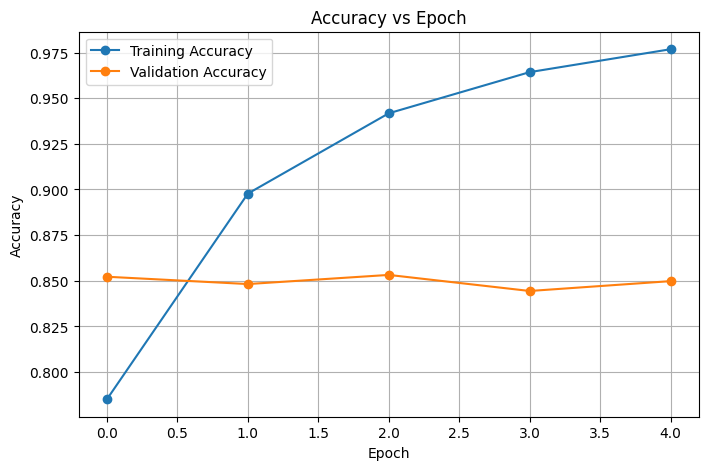

In [ ]:
# Visualize Accuracy vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


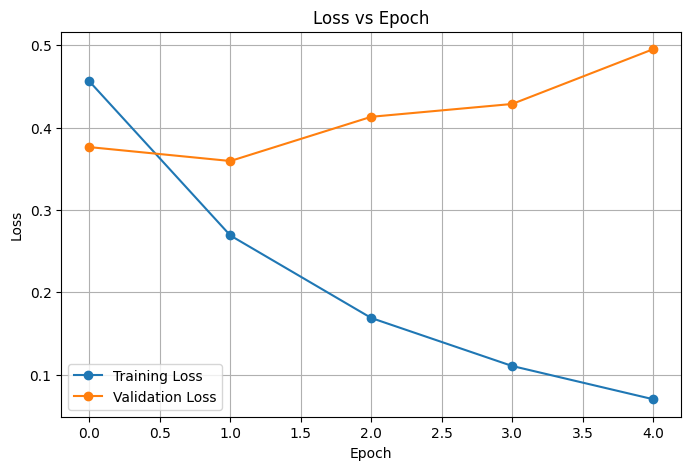

In [ ]:
# Visualize Loss vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Evaluate the trained model on the test dataset
test_loss, test_accuracy = model.evaluate(
    X_test_seq,
    y_test,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)


196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.8344 - loss: 0.5415
Test Loss     : 0.5415054559707642
Test Accuracy : 0.8343999981880188


In [ ]:
# Predictions and classification metrics
test_probabilities = model.predict(X_test_seq, batch_size=BATCH_SIZE, verbose=0).ravel()
test_predictions = (test_probabilities >= 0.5).astype(int)

accuracy = accuracy_score(y_test, test_predictions)
precision = precision_score(y_test, test_predictions, zero_division=0)
recall = recall_score(y_test, test_predictions, zero_division=0)
f1 = f1_score(y_test, test_predictions, zero_division=0)
cm = confusion_matrix(y_test, test_predictions)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

display(metrics_df)

print("\nClassification Report:")
print(classification_report(
    y_test,
    test_predictions,
    target_names=["Negative", "Positive"],
    zero_division=0
))


,Metric,Value
0,Accuracy,0.834400
1,Precision,0.831378
2,Recall,0.838960
3,F1-score,0.835152



Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.83      0.83     12500
    Positive       0.83      0.84      0.84     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



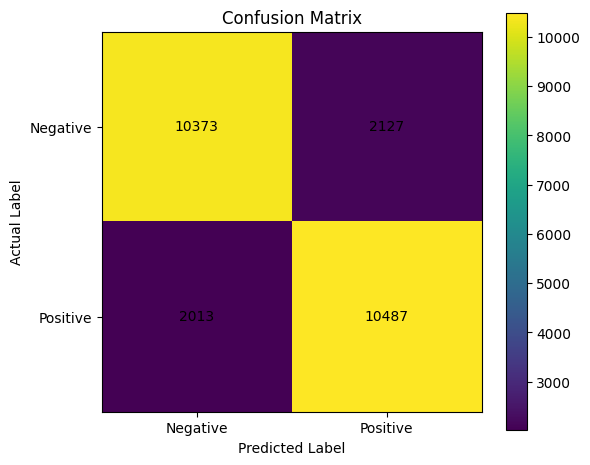

In [ ]:
# Confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


In [ ]:
# Predict sentiment for sample reviews
sample_reviews = [
    "This movie was fantastic and I really enjoyed every minute of it.",
    "The movie was boring, poorly written, and a complete waste of time.",
    "Excellent acting and a wonderful story. I would definitely recommend it.",
    "I did not enjoy this film. The plot was confusing and disappointing."
]

sample_clean = np.array([clean_text(x) for x in sample_reviews])
sample_seq = vectorizer(sample_clean).numpy()
sample_probs = model.predict(sample_seq, verbose=0).ravel()

for review, prob in zip(sample_reviews, sample_probs):
    sentiment = "Positive" if prob >= 0.5 else "Negative"
    print(f"Review    : {review}")
    print(f"Sentiment : {sentiment}")
    print(f"Confidence: {prob:.4f}")
    print("-" * 80)


Review    : This movie was fantastic and I really enjoyed every minute of it.
Sentiment : Positive
Confidence: 0.9359
--------------------------------------------------------------------------------
Review    : The movie was boring, poorly written, and a complete waste of time.
Sentiment : Negative
Confidence: 0.0025
--------------------------------------------------------------------------------
Review    : Excellent acting and a wonderful story. I would definitely recommend it.
Sentiment : Positive
Confidence: 0.9889
--------------------------------------------------------------------------------
Review    : I did not enjoy this film. The plot was confusing and disappointing.
Sentiment : Negative
Confidence: 0.0503
--------------------------------------------------------------------------------


# Expected Outcome

The LSTM model learns sequential information from textual data and classifies IMDB movie reviews into positive and negative sentiments. The experiment demonstrates text preprocessing, tokenization, sequence padding, embedding generation, LSTM model construction, training, visualization, and evaluation using accuracy, precision, recall, F1-score, and a confusion matrix.

## Dataset Link
https://ai.stanford.edu/~amaas/data/sentiment/

## Result
The final accuracy and other evaluation values are generated automatically when the notebook is executed. Results may vary slightly depending on TensorFlow version, hardware, and training configuration.
